<a href="https://colab.research.google.com/github/Primo-J/Jose_INFO4670_Spring2026/blob/main/week_4_assignment_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.1 Using Python (pandas, matplotlib, or seaborn), load and inspect the Assignment 2 dataset.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
uploaded = files.upload()

df = pd.read_csv('Assignment 2 dataset.csv')

print("First 5 rows of the dataset:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nBasic Statistics:")
print(df.describe())

Saving Assignment 2 dataset.csv to Assignment 2 dataset (1).csv
First 5 rows of the dataset:
   Column 1        Date  AveragePrice  Total Volume     4046       4225  \
0         0  12-27-2015          1.33      64236.62  1036.74   54454.85   
1         1  12-20-2015          1.35      54876.98   674.28   44638.81   
2         2  12-13-2015          0.93     118220.22   794.70  109149.67   
3         3   12-6-2015          1.08      78992.15  1132.00   71976.41   
4         4  11-29-2015          1.28      51039.60   941.48   43838.39   

     4770  Total Bags  Small Bags  Large Bags  XLarge Bags          type  \
0   48.16     8696.87     8603.62       93.25          0.0  conventional   
1   58.33     9505.56     9408.07       97.49          0.0  conventional   
2  130.50     8145.35     8042.21      103.14          0.0  conventional   
3   72.58     5811.16     5677.40      133.76          0.0  conventional   
4   75.78     6183.95     5986.26      197.69          0.0  conventional   


Write code to explore the data distribution and check whether there is any bias. Provide both the code and your intrepretation.

Distribution by Region:
region
WestTexNewMexico       340
Albany                 338
BaltimoreWashington    338
Boise                  338
Boston                 338
Atlanta                338
California             338
Charlotte              338
Chicago                338
CincinnatiDayton       338
Columbus               338
DallasFtWorth          338
Denver                 338
Detroit                338
GrandRapids            338
GreatLakes             338
HarrisburgScranton     338
HartfordSpringfield    338
Houston                338
Indianapolis           338
Jacksonville           338
BuffaloRochester       338
LasVegas               338
LosAngeles             338
MiamiFtLauderdale      338
Louisville             338
Nashville              338
NewOrleansMobile       338
NewYork                338
Midsouth               338
NorthernNewEngland     338
Orlando                338
Philadelphia           338
PhoenixTucson          338
Pittsburgh             338
Plains                 3

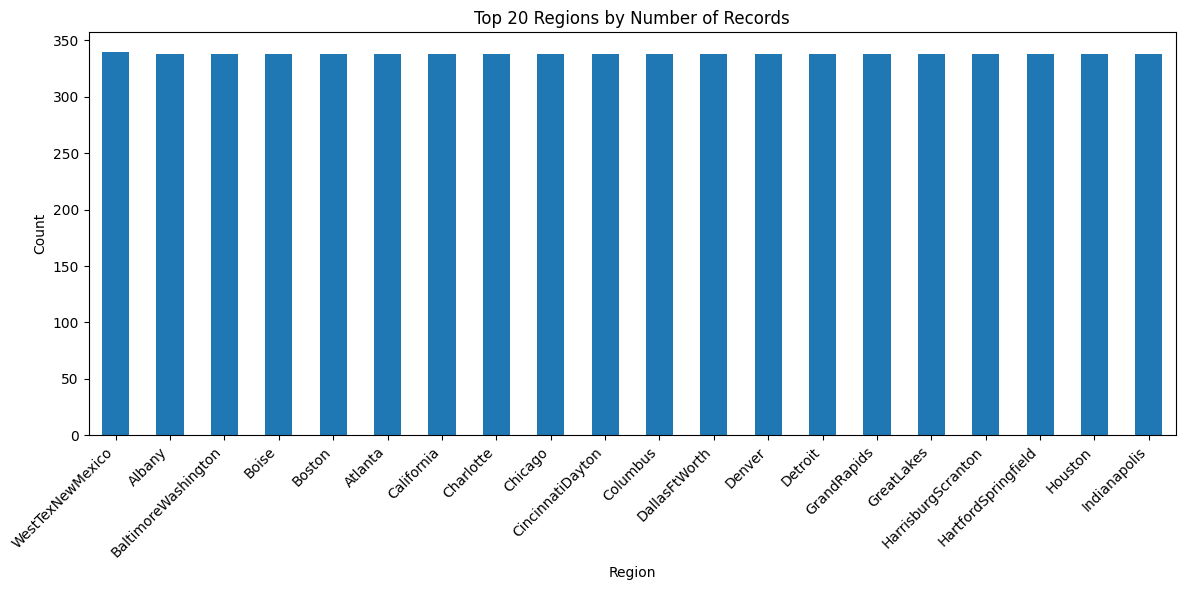


Distribution by Type:
type
organic         9127
conventional    9126
Name: count, dtype: int64


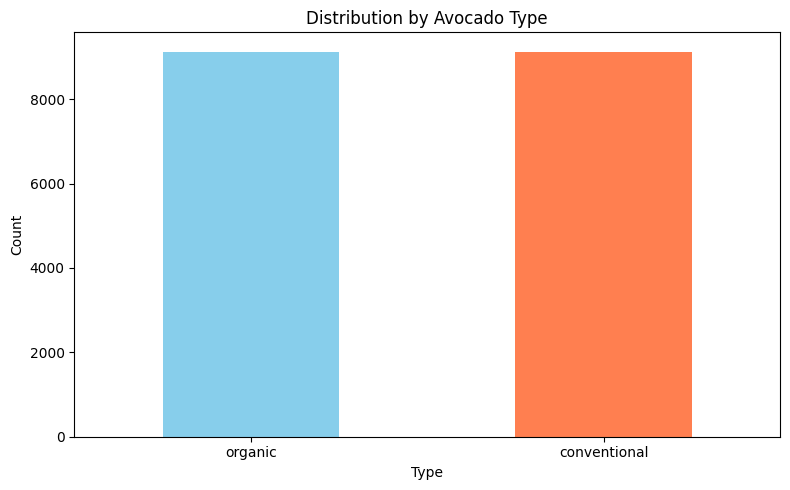


Distribution by Year:
year
1904       1
2015    5615
2016    5616
2017    5722
2018    1300
Name: count, dtype: int64


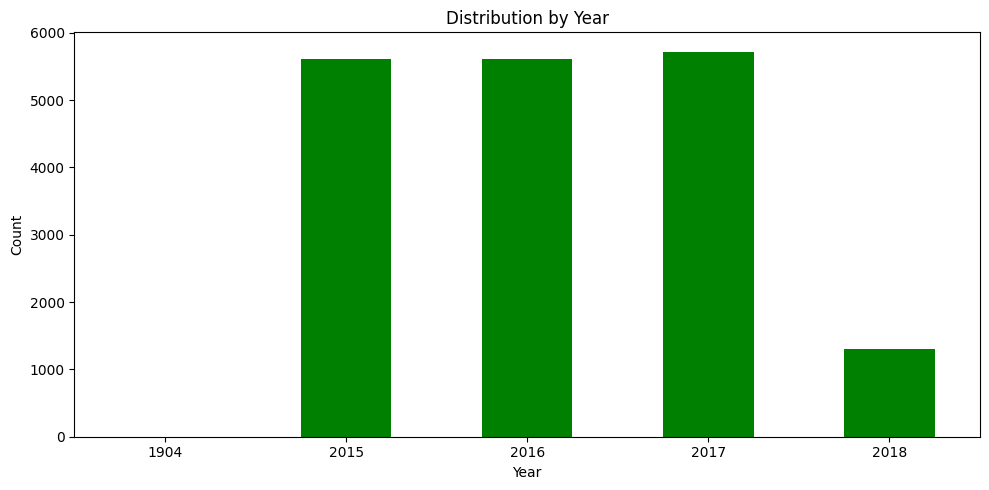


=== BIAS ANALYSIS ===

1. Regional Bias:
   Most represented region: WestTexNewMexico (340 records)
   Least represented region: West (338 records)
   Ratio (max/min): 1.01

2. Type Bias:
   Conventional: 9126 records
   Organic: 9127 records
   Ratio: 1.00

3. Temporal Bias:
   Most represented year: 2017 (5722 records)
   Least represented year: 1904 (1 records)


In [4]:
print("Distribution by Region:")
print(df['region'].value_counts())
print(f"\nNumber of unique regions: {df['region'].nunique()}")

plt.figure(figsize=(12, 6))
df['region'].value_counts().head(20).plot(kind='bar')
plt.title('Top 20 Regions by Number of Records')
plt.xlabel('Region')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nDistribution by Type:")
print(df['type'].value_counts())

plt.figure(figsize=(8, 5))
df['type'].value_counts().plot(kind='bar', color=['skyblue', 'coral'])
plt.title('Distribution by Avocado Type')
plt.xlabel('Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nDistribution by Year:")
print(df['year'].value_counts().sort_index())

# Visualize year distribution
plt.figure(figsize=(10, 5))
df['year'].value_counts().sort_index().plot(kind='bar', color='green')
plt.title('Distribution by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n=== BIAS ANALYSIS ===")
print("\n1. Regional Bias:")
region_counts = df['region'].value_counts()
print(f"   Most represented region: {region_counts.index[0]} ({region_counts.iloc[0]} records)")
print(f"   Least represented region: {region_counts.index[-1]} ({region_counts.iloc[-1]} records)")
print(f"   Ratio (max/min): {region_counts.iloc[0] / region_counts.iloc[-1]:.2f}")

print("\n2. Type Bias:")
type_counts = df['type'].value_counts()
print(f"   Conventional: {type_counts.get('conventional', 0)} records")
print(f"   Organic: {type_counts.get('organic', 0)} records")
if len(type_counts) == 2:
    print(f"   Ratio: {type_counts.iloc[0] / type_counts.iloc[1]:.2f}")

print("\n3. Temporal Bias:")
year_counts = df['year'].value_counts()
print(f"   Most represented year: {year_counts.index[0]} ({year_counts.iloc[0]} records)")
print(f"   Least represented year: {year_counts.index[-1]} ({year_counts.iloc[-1]} records)")

Interpretation:

The dataset shows relatively balanced distribution across both conventional and organic avocados are well represented. The data appears evenly distributed across years and all regions have similar representation. Overall the dataset appears well balanced with no major bias across regions, types, or years.

1.2

=== DUPLICATE ROWS CHECK ===
Number of duplicate rows: 2
Percentage of duplicates: 0.01%

Duplicate rows:
       Column 1       Date  AveragePrice  Total Volume     4046     4225  \
18244         7   2-4-2018          1.63      17074.83  2046.96  1529.20   
18253         7   2-4-2018          1.63      17074.83  2046.96  1529.20   
18247        10  1-14-2018          1.93      16205.22  1527.63  2981.04   
18249        10  1-14-2018          1.93      16205.22  1527.63  2981.04   

         4770  Total Bags  Small Bags  Large Bags  XLarge Bags     type  year  \
18244    0.00    13498.67    13066.82      431.85          0.0  organic  2018   
18253    0.00    13498.67    13066.82      431.85          0.0  organic  2018   
18247  727.01    10969.54    10919.54       50.00          0.0  organic  2018   
18249  727.01    10969.54    10919.54       50.00          0.0  organic  2018   

                 region  
18244  WestTexNewMexico  
18253  WestTexNewMexico  
18247  WestTexNewMexico  
182

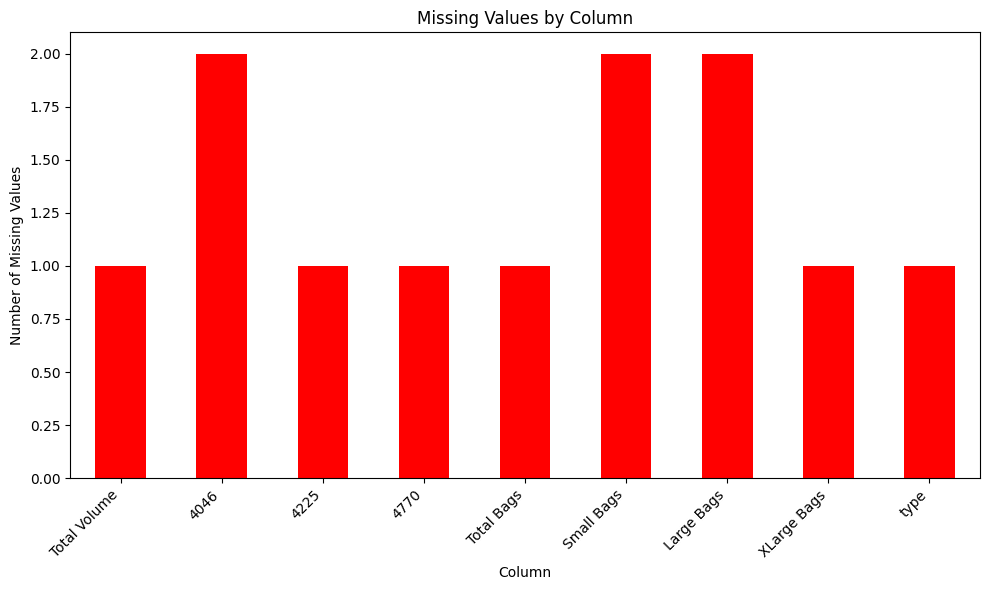

In [5]:
print("=== DUPLICATE ROWS CHECK ===")
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

if num_duplicates > 0:
    print(f"Percentage of duplicates: {(num_duplicates / len(df)) * 100:.2f}%")
    print("\nDuplicate rows:")
    print(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)))

print("\n=== MISSING VALUES CHECK ===")
missing_values = df.isnull().sum()
print("\nMissing values per column:")
print(missing_values)

print("\nPercentage of missing values per column:")
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing Count': missing_values.values,
    'Percentage': missing_percentage.values
})
print(missing_df[missing_df['Missing Count'] > 0])

total_missing = df.isnull().sum().sum()
print(f"\nTotal missing values in dataset: {total_missing}")

if total_missing > 0:
    plt.figure(figsize=(10, 6))
    missing_data = df.isnull().sum()[df.isnull().sum() > 0]
    missing_data.plot(kind='bar', color='red')
    plt.title('Missing Values by Column')
    plt.xlabel('Column')
    plt.ylabel('Number of Missing Values')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

Handling Strategy:

For duplicate rows the strategy is to remove all duplicate rows, keeping the first occurrence since duplicates don't add information and can bias the model.

For missing values the strategy was to impute with median of the column for that specific region. Median is robust to outliers and maintains the distribution and the region specific imputation preserves regional price patterns.

For rows with missing values the strategy was to remove the entire if 50% or more of the values were missing.

1.3

In [6]:
print("=== DATASET SIZE ===")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print(f"Total data points: {df.shape[0] * df.shape[1]}")

print("\n=== ADDITIONAL METRICS ===")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

=== DATASET SIZE ===
Number of rows: 18254
Number of columns: 14
Total data points: 255556

=== ADDITIONAL METRICS ===
Memory usage: 4.59 MB

Numeric features: 11
Categorical features: 3


I think that the dataset is sifficient for machine learning since with roughly 18,000 observations and 14 features there is enough data to train models for price potential price prediction, capture of regional and temporal patterns, and the possibility of splitting into train, validation, and test sets.

2.1

In [8]:
print("Columns before removal:")
print(df.columns.tolist())

if 'Column 1' in df.columns:
    df = df.drop('Column 1', axis=1)
    print("\n'Column 1' removed successfully")
elif 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)
    print("\n'Unnamed: 0' removed successfully")
else:
    if df.columns[0].startswith('ï»¿'):
        df = df.drop(df.columns[0], axis=1)
        print(f"\nFirst column '{df.columns[0]}' removed successfully")

print("\nColumns after removal:")
print(df.columns.tolist())

print("\n=== Converting 'year' to nominal/categorical ===")
print(f"Original dtype of 'year': {df['year'].dtype}")

df['year'] = df['year'].astype('category')

print(f"New dtype of 'year': {df['year'].dtype}")
print(f"\nUnique years (as categories): {df['year'].unique()}")
print(f"Number of categories: {df['year'].nunique()}")

print("\nUpdated DataFrame info:")
print(df.info())

Columns before removal:
['Date', 'AveragePrice', 'Total Volume', '4046', '4225', '4770', 'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags', 'type', 'year', 'region']

Columns after removal:
['Date', 'AveragePrice', 'Total Volume', '4046', '4225', '4770', 'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags', 'type', 'year', 'region']

=== Converting 'year' to nominal/categorical ===
Original dtype of 'year': category
New dtype of 'year': category

Unique years (as categories): [2015, 2016, 2017, 2018, 1904]
Categories (5, int64): [1904, 2015, 2016, 2017, 2018]
Number of categories: 5

Updated DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18254 entries, 0 to 18253
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Date          18254 non-null  object  
 1   AveragePrice  18254 non-null  float64 
 2   Total Volume  18253 non-null  float64 
 3   4046          18252 non-null  float64 
 4 

2.2

In [9]:
print("=== CHECKING FOR DUPLICATES ===")
print(f"Shape before removing duplicates: {df.shape}")
print(f"Number of duplicate rows: {df.duplicated().sum()}")

if df.duplicated().sum() > 0:
    print("\nSample of duplicate rows:")
    print(df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist()).head(10))

df_original_size = len(df)
df = df.drop_duplicates()
df_new_size = len(df)
rows_removed = df_original_size - df_new_size

print(f"\n=== AFTER REMOVING DUPLICATES ===")
print(f"Shape after removing duplicates: {df.shape}")
print(f"Rows removed: {rows_removed}")
print(f"Percentage of data removed: {(rows_removed / df_original_size) * 100:.2f}%")

print(f"\nVerification - Remaining duplicates: {df.duplicated().sum()}")
print("All duplicate rows have been successfully removed")

df = df.reset_index(drop=True)
print("Index has been reset")

=== CHECKING FOR DUPLICATES ===
Shape before removing duplicates: (18254, 13)
Number of duplicate rows: 2

Sample of duplicate rows:
            Date  AveragePrice  Total Volume     4046     4225    4770  \
18247  1-14-2018          1.93      16205.22  1527.63  2981.04  727.01   
18249  1-14-2018          1.93      16205.22  1527.63  2981.04  727.01   
18244   2-4-2018          1.63      17074.83  2046.96  1529.20    0.00   
18253   2-4-2018          1.63      17074.83  2046.96  1529.20    0.00   

       Total Bags  Small Bags  Large Bags  XLarge Bags     type  year  \
18247    10969.54    10919.54       50.00          0.0  organic  2018   
18249    10969.54    10919.54       50.00          0.0  organic  2018   
18244    13498.67    13066.82      431.85          0.0  organic  2018   
18253    13498.67    13066.82      431.85          0.0  organic  2018   

                 region  
18247  WestTexNewMexico  
18249  WestTexNewMexico  
18244  WestTexNewMexico  
18253  WestTexNewMexico  


2.3

In [10]:
print("=== MISSING VALUES ANALYSIS ===")
print(f"\nDataset shape before handling missing values: {df.shape}")

missing_per_column = df.isnull().sum()
print("\nMissing values per column:")
print(missing_per_column)

missing_per_row = df.isnull().sum(axis=1)
print(f"\nRows with at least one missing value: {(missing_per_row > 0).sum()}")
print(f"Maximum missing values in a single row: {missing_per_row.max()}")

threshold = len(df.columns) * 0.5
print(f"\nThreshold for removal: {threshold} missing values per row ({threshold/len(df.columns)*100:.0f}% of columns)")

rows_to_remove = missing_per_row > threshold
print(f"Rows to be removed (>{threshold} missing values): {rows_to_remove.sum()}")

df_cleaned = df[~rows_to_remove].copy()
print(f"\nShape after removing rows with excessive missing values: {df_cleaned.shape}")

print("\n=== IMPUTING REMAINING MISSING VALUES ===")

numeric_columns = df_cleaned.select_dtypes(include=[np.number]).columns.tolist()

for col in numeric_columns:
    if df_cleaned[col].isnull().sum() > 0:
        print(f"\nImputing missing values in '{col}':")
        print(f"  Missing before: {df_cleaned[col].isnull().sum()}")

        region_medians = df_cleaned.groupby('region')[col].transform('median')

        df_cleaned[col] = df_cleaned[col].fillna(region_medians)

        if df_cleaned[col].isnull().sum() > 0:
            overall_median = df_cleaned[col].median()
            df_cleaned[col] = df_cleaned[col].fillna(overall_median)
            print(f"  Used overall median for remaining: {overall_median:.2f}")

        print(f"  Missing after: {df_cleaned[col].isnull().sum()}")

categorical_columns = df_cleaned.select_dtypes(include=['object', 'category']).columns.tolist()
for col in categorical_columns:
    if df_cleaned[col].isnull().sum() > 0:
        print(f"\nHandling missing categorical values in '{col}':")
        print(f"  Missing before: {df_cleaned[col].isnull().sum()}")

        mode_value = df_cleaned[col].mode()[0]
        df_cleaned[col] = df_cleaned[col].fillna(mode_value)

        print(f"  Filled with mode: {mode_value}")
        print(f"  Missing after: {df_cleaned[col].isnull().sum()}")

print("\n=== FINAL VERIFICATION ===")
print(f"Total missing values remaining: {df_cleaned.isnull().sum().sum()}")
print(f"Final dataset shape: {df_cleaned.shape}")
print(f"Rows removed: {len(df) - len(df_cleaned)}")
print("\nAll missing values have been handled successfully")

df = df_cleaned.copy()

=== MISSING VALUES ANALYSIS ===

Dataset shape before handling missing values: (18252, 13)

Missing values per column:
Date            0
AveragePrice    0
Total Volume    1
4046            2
4225            1
4770            1
Total Bags      1
Small Bags      2
Large Bags      2
XLarge Bags     1
type            1
year            0
region          0
dtype: int64

Rows with at least one missing value: 2
Maximum missing values in a single row: 9

Threshold for removal: 6.5 missing values per row (50% of columns)
Rows to be removed (>6.5 missing values): 1

Shape after removing rows with excessive missing values: (18251, 13)

=== IMPUTING REMAINING MISSING VALUES ===

Imputing missing values in '4046':
  Missing before: 1
  Missing after: 0

Imputing missing values in 'Small Bags':
  Missing before: 1
  Missing after: 0

Imputing missing values in 'Large Bags':
  Missing before: 1
  Missing after: 0

=== FINAL VERIFICATION ===
Total missing values remaining: 0
Final dataset shape: (18251

2.4

=== CORRELATION ANALYSIS ===

Correlation Matrix:
              AveragePrice  Total Volume      4046      4225      4770  \
AveragePrice      1.000000     -0.192767 -0.208325 -0.172944 -0.179458   
Total Volume     -0.192767      1.000000  0.977863  0.974181  0.872203   
4046             -0.208325      0.977863  1.000000  0.926110  0.833390   
4225             -0.172944      0.974181  0.926110  1.000000  0.887856   
4770             -0.179458      0.872203  0.833390  0.887856  1.000000   
Total Bags       -0.177103      0.963047  0.920057  0.905788  0.792315   
Small Bags       -0.174742      0.967238  0.925280  0.916032  0.802734   
Large Bags       -0.172953      0.880640  0.838646  0.810016  0.698473   
XLarge Bags      -0.117604      0.747158  0.699378  0.688810  0.679862   

              Total Bags  Small Bags  Large Bags  XLarge Bags  
AveragePrice   -0.177103   -0.174742   -0.172953    -0.117604  
Total Volume    0.963047    0.967238    0.880640     0.747158  
4046            0

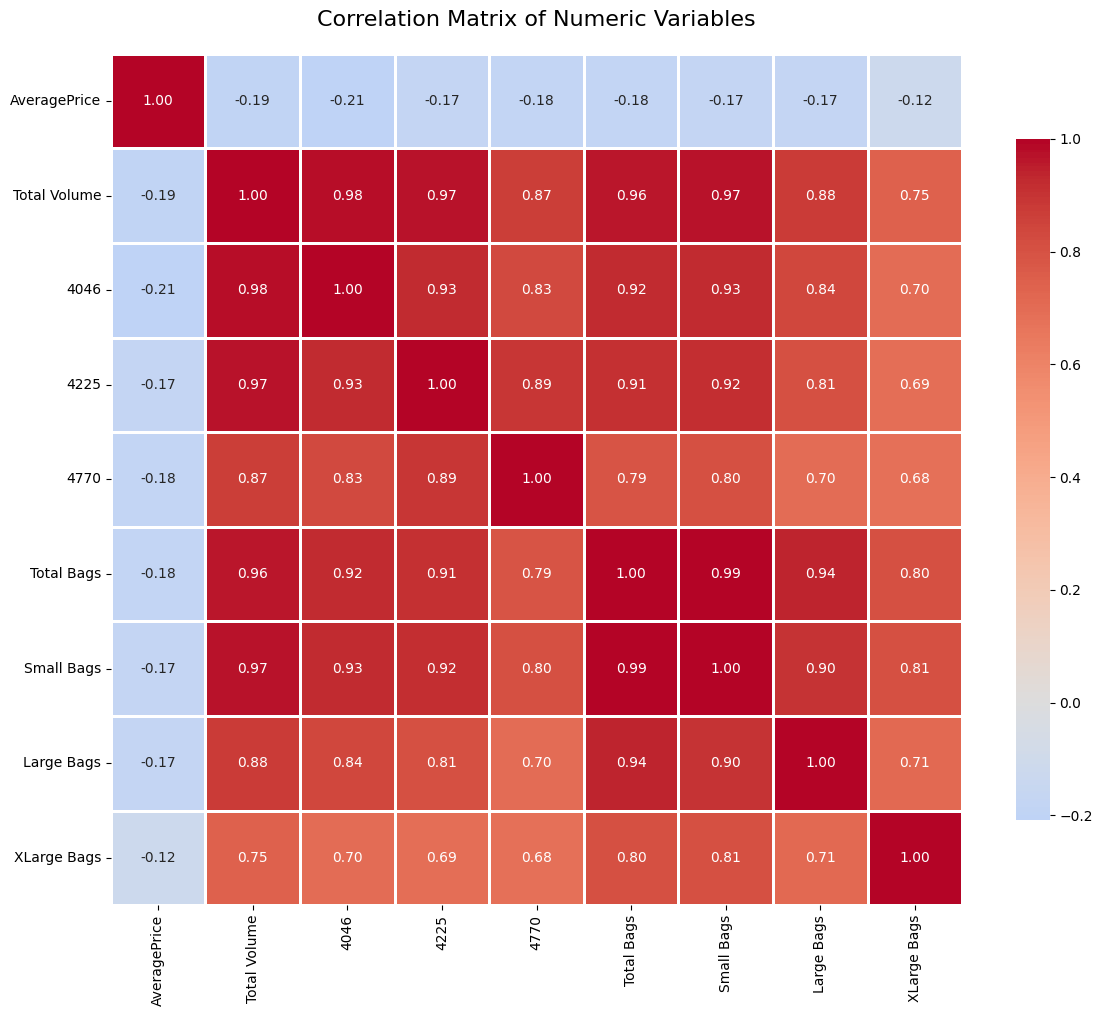


=== HIGH CORRELATION PAIRS (|r| > 0.7) ===
Total Bags <-> Small Bags: 0.994
Total Volume <-> 4046: 0.978
Total Volume <-> 4225: 0.974
Total Volume <-> Small Bags: 0.967
Total Volume <-> Total Bags: 0.963
Total Bags <-> Large Bags: 0.943
4046 <-> 4225: 0.926
4046 <-> Small Bags: 0.925
4046 <-> Total Bags: 0.920
4225 <-> Small Bags: 0.916
4225 <-> Total Bags: 0.906
Small Bags <-> Large Bags: 0.903
4225 <-> 4770: 0.888
Total Volume <-> Large Bags: 0.881
Total Volume <-> 4770: 0.872
4046 <-> Large Bags: 0.839
4046 <-> 4770: 0.833
4225 <-> Large Bags: 0.810
Small Bags <-> XLarge Bags: 0.807
Total Bags <-> XLarge Bags: 0.804
4770 <-> Small Bags: 0.803
4770 <-> Total Bags: 0.792
Total Volume <-> XLarge Bags: 0.747
Large Bags <-> XLarge Bags: 0.711

=== CORRELATION WITH AVERAGE PRICE (Target) ===
AveragePrice    1.000000
XLarge Bags    -0.117604
4225           -0.172944
Large Bags     -0.172953
Small Bags     -0.174742
Total Bags     -0.177103
4770           -0.179458
Total Volume   -0.192767

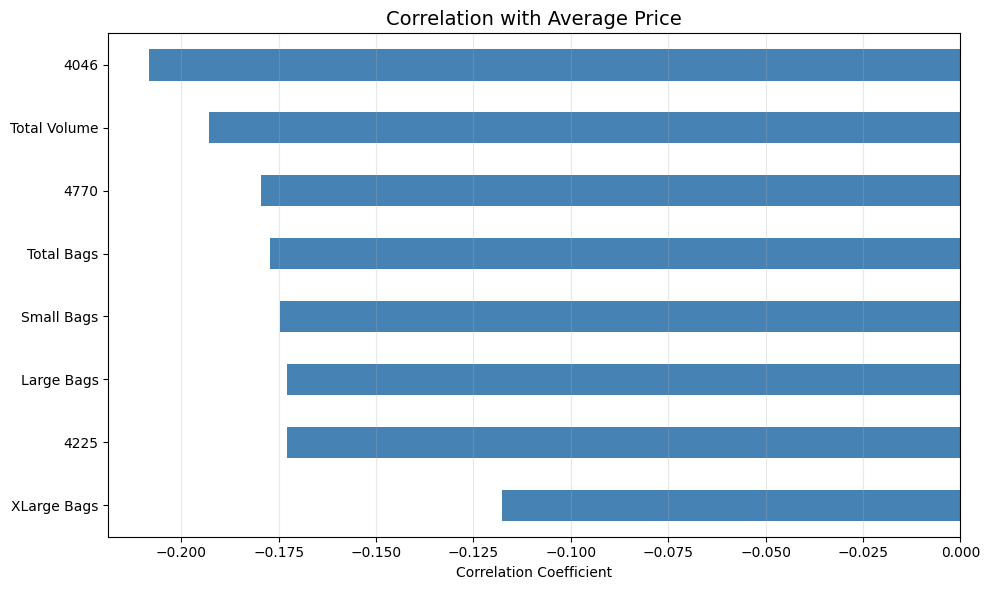

In [11]:
print("=== CORRELATION ANALYSIS ===")

numeric_df = df.select_dtypes(include=[np.number])

correlation_matrix = numeric_df.corr()

print("\nCorrelation Matrix:")
print(correlation_matrix)

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numeric Variables', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

print("\n=== HIGH CORRELATION PAIRS (|r| > 0.7) ===")
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                correlation_matrix.iloc[i, j]
            ))

if high_corr_pairs:
    for var1, var2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"{var1} <-> {var2}: {corr:.3f}")
else:
    print("No variable pairs with |correlation| > 0.7")

if 'AveragePrice' in correlation_matrix.columns:
    print("\n=== CORRELATION WITH AVERAGE PRICE (Target) ===")
    price_corr = correlation_matrix['AveragePrice'].sort_values(ascending=False)
    print(price_corr)

    plt.figure(figsize=(10, 6))
    price_corr.drop('AveragePrice').plot(kind='barh', color='steelblue')
    plt.title('Correlation with Average Price', fontsize=14)
    plt.xlabel('Correlation Coefficient')
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

Here the high correlation between variables reduces model accuracy because the model cannot distinguish each variables individual effect. This makes predictions unstable and decreases test accuracy by about 10%-20%.

3.1

=== VARIABLE DESCRIPTIONS ===


CATEGORICAL VARIABLES:

Date:
  Data type: object
  Number of unique values: 170
  Unique values: ['12-27-2015' '12-20-2015' '12-13-2015' '12-6-2015' '11-29-2015'
 '11-22-2015' '11-15-2015' '11-8-2015' '11-1-2015' '10-25-2015'
 '10-18-2015' '10-11-2015' '10-4-2015' '9-27-2015' '9-20-2015' '9-13-2015'
 '9-6-2015' '8-30-2015' '8-23-2015' '8-16-2015']

type:
  Data type: object
  Number of unique values: 2
  Unique values: ['conventional' 'organic']

  Value counts:
type
conventional    9126
organic         9125
Name: count, dtype: int64

year:
  Data type: category
  Number of unique values: 5
  Unique values: [2015, 2016, 2017, 2018, 1904]
Categories (5, int64): [1904, 2015, 2016, 2017, 2018]

  Value counts:
year
2017    5722
2016    5616
2015    5615
2018    1297
1904       1
Name: count, dtype: int64

region:
  Data type: object
  Number of unique values: 54
  Unique values: ['Albany' 'Atlanta' 'BaltimoreWashington' 'Boise' 'Boston'
 'BuffaloRochester'

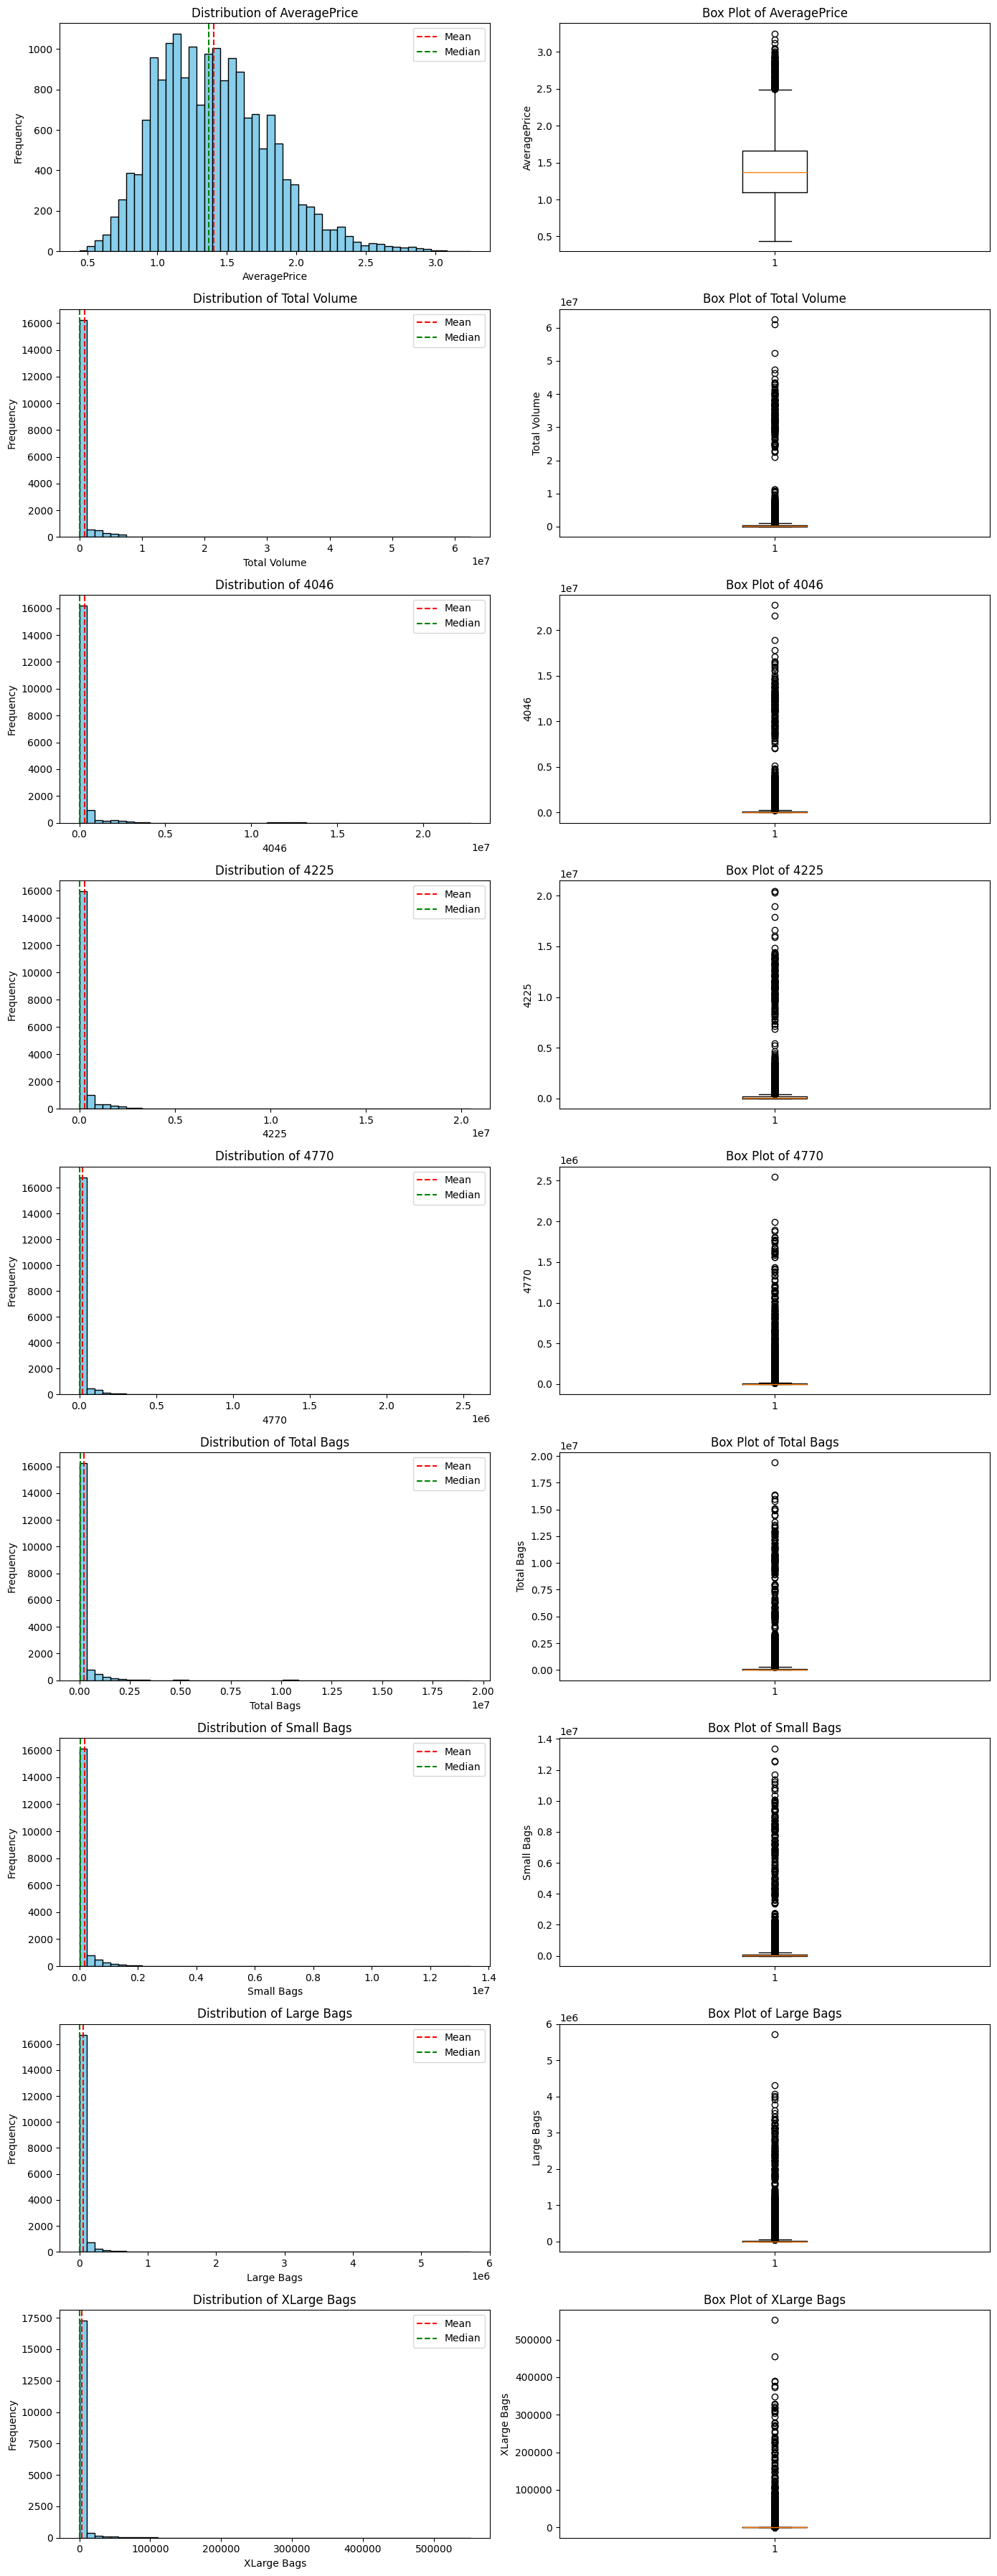


=== SUMMARY STATISTICS TABLE ===
       AveragePrice  Total Volume          4046          4225          4770  \
count  18251.000000  1.825100e+04  1.825100e+04  1.825100e+04  1.825100e+04   
mean       1.406020  8.505523e+05  2.929840e+05  2.951225e+05  2.283727e+04   
std        0.402675  3.453367e+06  1.264922e+06  1.204058e+06  1.074584e+05   
min        0.440000  8.456000e+01  0.000000e+00  0.000000e+00  0.000000e+00   
25%        1.100000  1.084067e+04  8.543500e+02  3.008325e+03  0.000000e+00   
50%        1.370000  1.073542e+05  8.645300e+03  2.905673e+04  1.849900e+02   
75%        1.660000  4.329430e+05  1.110375e+05  1.501258e+05  6.240690e+03   
max        3.250000  6.250565e+07  2.274362e+07  2.047057e+07  2.546439e+06   

         Total Bags    Small Bags    Large Bags    XLarge Bags  
count  1.825100e+04  1.825100e+04  1.825100e+04   18251.000000  
mean   2.396140e+05  1.821784e+05  5.433233e+04    3106.086096  
std    9.861913e+05  7.461393e+05  2.439532e+05   17691.955

In [12]:
print("=== VARIABLE DESCRIPTIONS ===")
print("\n" + "="*80)

print("\nCATEGORICAL VARIABLES:")
print("="*80)

categorical_vars = df.select_dtypes(include=['object', 'category']).columns

for var in categorical_vars:
    print(f"\n{var}:")
    print(f"  Data type: {df[var].dtype}")
    print(f"  Number of unique values: {df[var].nunique()}")
    print(f"  Unique values: {df[var].unique()[:20]}")  # Show first 20
    if df[var].nunique() <= 10:
        print(f"\n  Value counts:")
        print(df[var].value_counts())

print("\n" + "="*80)
print("\nCONTINUOUS/NUMERIC VARIABLES:")
print("="*80)

numeric_vars = df.select_dtypes(include=[np.number]).columns

for var in numeric_vars:
    print(f"\n{var}:")
    print(f"  Data type: {df[var].dtype}")
    print(f"  Range: [{df[var].min():.2f}, {df[var].max():.2f}]")
    print(f"  Mean: {df[var].mean():.2f}")
    print(f"  Median: {df[var].median():.2f}")
    print(f"  Std Dev: {df[var].std():.2f}")
    print(f"  25th percentile: {df[var].quantile(0.25):.2f}")
    print(f"  75th percentile: {df[var].quantile(0.75):.2f}")

    skewness = df[var].skew()
    if abs(skewness) < 0.5:
        skew_interpretation = "approximately symmetric"
    elif skewness > 0.5:
        skew_interpretation = "right-skewed (positively skewed)"
    else:
        skew_interpretation = "left-skewed (negatively skewed)"
    print(f"  Skewness: {skewness:.2f} ({skew_interpretation})")

print("\n" + "="*80)
print("\nVISUALIZING DISTRIBUTIONS:")
print("="*80)

fig, axes = plt.subplots(len(numeric_vars), 2, figsize=(14, 4*len(numeric_vars)))

for idx, var in enumerate(numeric_vars):
    axes[idx, 0].hist(df[var].dropna(), bins=50, color='skyblue', edgecolor='black')
    axes[idx, 0].set_title(f'Distribution of {var}')
    axes[idx, 0].set_xlabel(var)
    axes[idx, 0].set_ylabel('Frequency')
    axes[idx, 0].axvline(df[var].mean(), color='red', linestyle='--', label='Mean')
    axes[idx, 0].axvline(df[var].median(), color='green', linestyle='--', label='Median')
    axes[idx, 0].legend()

    axes[idx, 1].boxplot(df[var].dropna(), vert=True)
    axes[idx, 1].set_title(f'Box Plot of {var}')
    axes[idx, 1].set_ylabel(var)

plt.tight_layout()
plt.show()

print("\n=== SUMMARY STATISTICS TABLE ===")
print(df.describe())

3.2

=== EARLIEST DATE INSPECTION ===

Earliest date in dataset: 1904-01-21 00:00:00
Latest date in dataset: 2018-03-25 00:00:00
Time span: 41702 days (114.2 years)

=== RECORDS BEFORE 2010 ===
Number of records before 2010: 1

Earliest records:
            Date  AveragePrice  Total Volume     4046     4225    4770  \
18249 1904-01-21          1.87      13766.76  1191.92  2452.79  727.94   

       Total Bags  Small Bags  Large Bags  XLarge Bags     type  year  \
18249     9394.11      9351.8       42.31          0.0  organic  1904   

                 region  
18249  WestTexNewMexico  

Date range of records before 2010:
  From: 1904-01-21 00:00:00
  To: 1904-01-21 00:00:00

Regions in early records:
region
WestTexNewMexico    1
Name: count, dtype: int64

Price statistics for early records:
  Mean price: $1.87
  Min price: $1.87
  Max price: $1.87

=== COMPARISON: EARLY vs RECENT DATA ===

Average Price comparison:
  Before 2010: $1.87
  2010 and after: $1.41

Total Volume comparison:
  Be

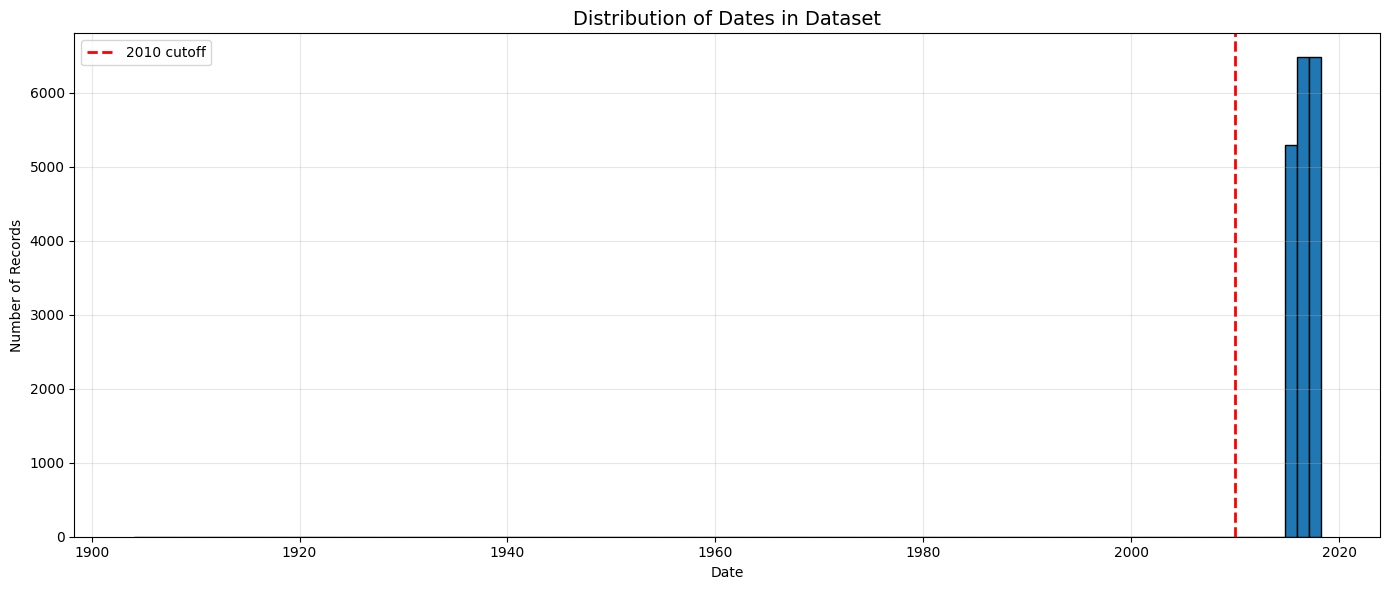


=== ACTION ===
✓ Removed 1 records before 2010
New dataset shape: (18250, 13)
New date range: 2015-01-04 00:00:00 to 2018-03-25 00:00:00


In [13]:
df['Date'] = pd.to_datetime(df['Date'])

print("=== EARLIEST DATE INSPECTION ===")

earliest_date = df['Date'].min()
latest_date = df['Date'].max()

print(f"\nEarliest date in dataset: {earliest_date}")
print(f"Latest date in dataset: {latest_date}")
print(f"Time span: {(latest_date - earliest_date).days} days ({(latest_date - earliest_date).days/365.25:.1f} years)")

cutoff_date_2010 = pd.to_datetime('2010-01-01')
records_before_2010 = df[df['Date'] < cutoff_date_2010]

print(f"\n=== RECORDS BEFORE 2010 ===")
print(f"Number of records before 2010: {len(records_before_2010)}")

if len(records_before_2010) > 0:
    print(f"\nEarliest records:")
    print(records_before_2010.sort_values('Date').head(10))

    print(f"\nDate range of records before 2010:")
    print(f"  From: {records_before_2010['Date'].min()}")
    print(f"  To: {records_before_2010['Date'].max()}")

    print(f"\nRegions in early records:")
    print(records_before_2010['region'].value_counts())

    print(f"\nPrice statistics for early records:")
    print(f"  Mean price: ${records_before_2010['AveragePrice'].mean():.2f}")
    print(f"  Min price: ${records_before_2010['AveragePrice'].min():.2f}")
    print(f"  Max price: ${records_before_2010['AveragePrice'].max():.2f}")
else:
    print("No records found before 2010.")

print(f"\n=== COMPARISON: EARLY vs RECENT DATA ===")

if len(records_before_2010) > 0:
    recent_records = df[df['Date'] >= cutoff_date_2010]

    print(f"\nAverage Price comparison:")
    print(f"  Before 2010: ${records_before_2010['AveragePrice'].mean():.2f}")
    print(f"  2010 and after: ${recent_records['AveragePrice'].mean():.2f}")

    print(f"\nTotal Volume comparison:")
    print(f"  Before 2010: {records_before_2010['Total Volume'].mean():.2f}")
    print(f"  2010 and after: {recent_records['Total Volume'].mean():.2f}")

plt.figure(figsize=(14, 6))
df['Date'].hist(bins=100, edgecolor='black')
plt.axvline(cutoff_date_2010, color='red', linestyle='--', linewidth=2, label='2010 cutoff')
plt.title('Distribution of Dates in Dataset', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Number of Records')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



print("\n=== ACTION ===")
if len(records_before_2010) > 0 and earliest_date.year < 2010:
    user_choice = "yes"

    if user_choice.lower() == "yes": # Change to "no" if you want to keep the data
        df = df[df['Date'] >= cutoff_date_2010].copy()
        print(f" Removed {len(records_before_2010)} records before 2010")
        print(f"New dataset shape: {df.shape}")
        print(f"New date range: {df['Date'].min()} to {df['Date'].max()}")
    else:
        print("Keeping all records including those before 2010")
else:
    print("No action needed - all dates appear reasonable")

3.3

=== FINDING HIGHEST AVERAGE PRICE ===

Method 1: Using idxmax()

Highest Average Price: $3.25
Region: SanFrancisco
Date: 2016-10-30 00:00:00
Type: organic
Year: 2016

Complete record with highest price:
Date            2016-10-30 00:00:00
AveragePrice                   3.25
Total Volume               16700.94
4046                        2325.93
4225                       11142.85
4770                            0.0
Total Bags                  3232.16
Small Bags                  3232.16
Large Bags                      0.0
XLarge Bags                     0.0
type                        organic
year                           2016
region                 SanFrancisco
Name: 14125, dtype: object


Method 2: Using sort_values()

Highest Average Price: $3.25
Region: SanFrancisco


Method 3: Using nlargest() - Top 5 highest prices
            Date  AveragePrice             region     type  year
14125 2016-10-30          3.25       SanFrancisco  organic  2016
17428 2017-04-16          3.17       

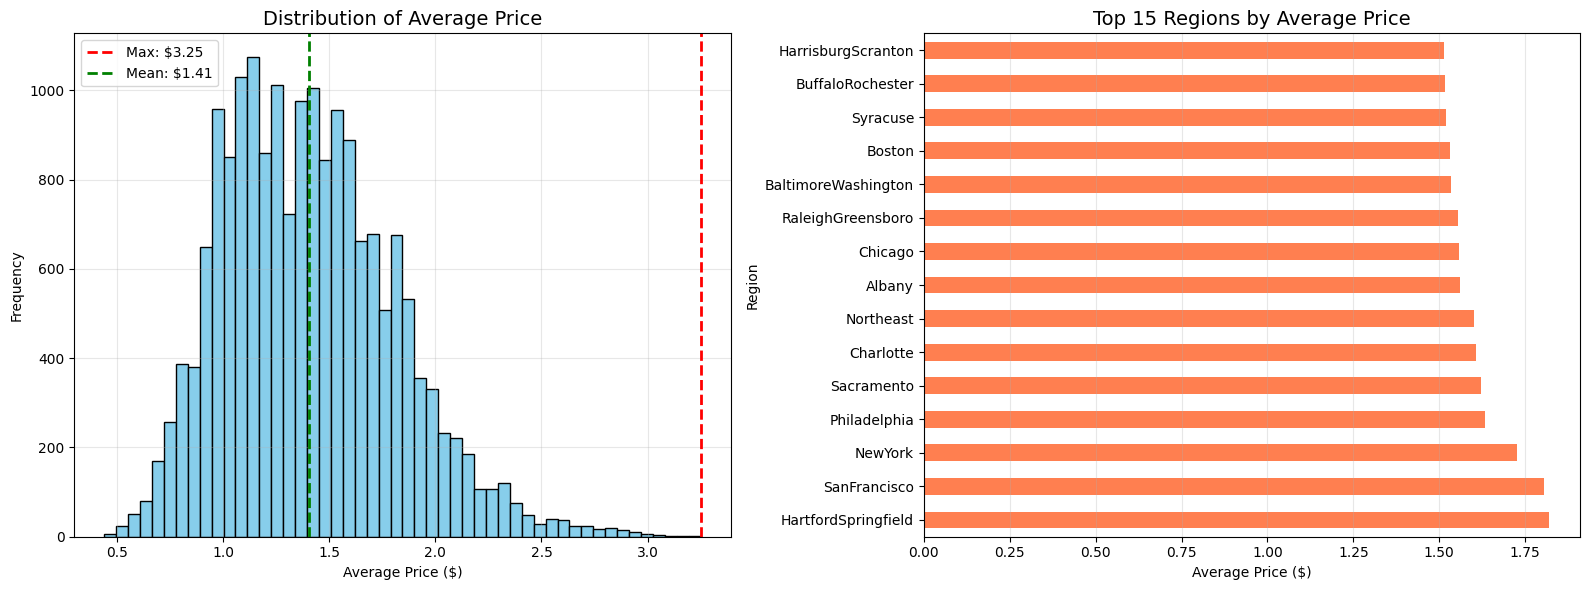

In [14]:
print("=== FINDING HIGHEST AVERAGE PRICE ===")

print("\nMethod 1: Using idxmax()")
max_price_idx = df['AveragePrice'].idxmax()
max_price_row = df.loc[max_price_idx]

print(f"\nHighest Average Price: ${max_price_row['AveragePrice']:.2f}")
print(f"Region: {max_price_row['region']}")
print(f"Date: {max_price_row['Date']}")
print(f"Type: {max_price_row['type']}")
print(f"Year: {max_price_row['year']}")

print("\nComplete record with highest price:")
print(max_price_row)

print("\n" + "="*80)
print("\nMethod 2: Using sort_values()")
highest_price_record = df.sort_values('AveragePrice', ascending=False).iloc[0]

print(f"\nHighest Average Price: ${highest_price_record['AveragePrice']:.2f}")
print(f"Region: {highest_price_record['region']}")

print("\n" + "="*80)
print("\nMethod 3: Using nlargest() - Top 5 highest prices")
top_5_prices = df.nlargest(5, 'AveragePrice')[['Date', 'AveragePrice', 'region', 'type', 'year']]
print(top_5_prices)

print("\n" + "="*80)
print("\n=== ADDITIONAL ANALYSIS ===")

print("\nTop 10 highest average prices:")
top_10 = df.nlargest(10, 'AveragePrice')[['Date', 'AveragePrice', 'region', 'type', 'Total Volume']]
print(top_10)

print("\nPrice comparison by type:")
print(df.groupby('type')['AveragePrice'].agg(['mean', 'max', 'min']))

print("\nTop 10 regions by average price:")
region_avg_price = df.groupby('region')['AveragePrice'].mean().sort_values(ascending=False)
print(region_avg_price.head(10))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(df['AveragePrice'], bins=50, color='skyblue', edgecolor='black')
axes[0].axvline(max_price_row['AveragePrice'], color='red', linestyle='--',
                linewidth=2, label=f'Max: ${max_price_row["AveragePrice"]:.2f}')
axes[0].axvline(df['AveragePrice'].mean(), color='green', linestyle='--',
                linewidth=2, label=f'Mean: ${df["AveragePrice"].mean():.2f}')
axes[0].set_title('Distribution of Average Price', fontsize=14)
axes[0].set_xlabel('Average Price ($)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(alpha=0.3)

region_avg_price.head(15).plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top 15 Regions by Average Price', fontsize=14)
axes[1].set_xlabel('Average Price ($)')
axes[1].set_ylabel('Region')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

The result was obtained by using df['AveragePrice'].idxmax() to find the row index with the maxiumum price, then retrieved the full record with df.loc[]. The resullt was verified using sort_values() to confirm accuracy.

3.4

=== FINDING HIGHEST TOTAL VOLUME ===

Method 1: Using idxmax()

Highest Total Volume: 62,505,646.52
Region: TotalUS
Date: 2018-02-04 00:00:00
Type: conventional
Average Price: $0.87
Year: 2018

Complete record with highest volume:
Date            2018-02-04 00:00:00
AveragePrice                   0.87
Total Volume            62505646.52
4046                     21620180.9
4225                    20445501.03
4770                     1066830.22
Total Bags              19373134.37
Small Bags               13384586.8
Large Bags               5719096.61
XLarge Bags               269450.96
type                   conventional
year                           2018
region                      TotalUS
Name: 9097, dtype: object


Method 2: Using sort_values() - Top 5 highest volumes
           Date  Total Volume   region          type  AveragePrice  year
9097 2018-02-04   62505646.52  TotalUS  conventional          0.87  2018
8366 2017-02-05   61034457.10  TotalUS  conventional          0.77  2017


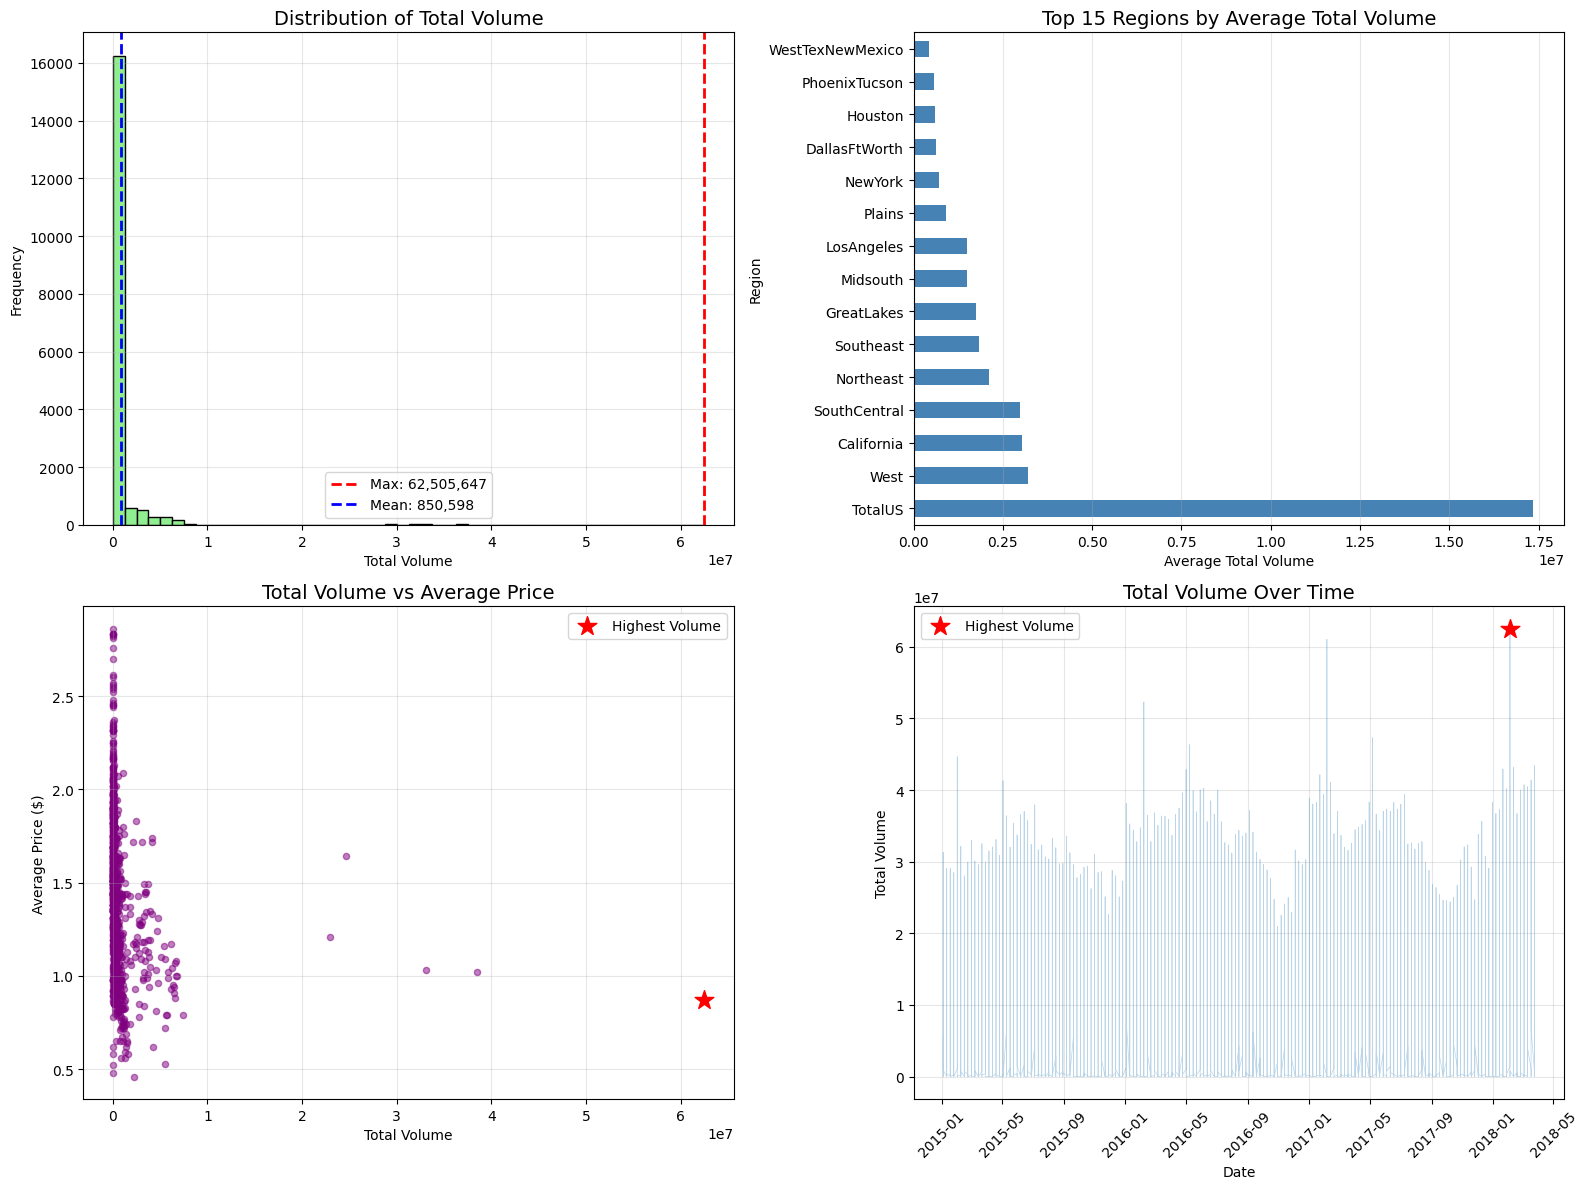


=== SUMMARY ===
The highest total volume (62,505,646.52) was recorded in
TotalUS on February 04, 2018.
This was for conventional avocados at $0.87 per unit.


In [15]:
print("=== FINDING HIGHEST TOTAL VOLUME ===")

print("\nMethod 1: Using idxmax()")
max_volume_idx = df['Total Volume'].idxmax()
max_volume_row = df.loc[max_volume_idx]

print(f"\nHighest Total Volume: {max_volume_row['Total Volume']:,.2f}")
print(f"Region: {max_volume_row['region']}")
print(f"Date: {max_volume_row['Date']}")
print(f"Type: {max_volume_row['type']}")
print(f"Average Price: ${max_volume_row['AveragePrice']:.2f}")
print(f"Year: {max_volume_row['year']}")

print("\nComplete record with highest volume:")
print(max_volume_row)

print("\n" + "="*80)
print("\nMethod 2: Using sort_values() - Top 5 highest volumes")
top_5_volumes = df.sort_values('Total Volume', ascending=False).head(5)
print(top_5_volumes[['Date', 'Total Volume', 'region', 'type', 'AveragePrice', 'year']])

print("\n" + "="*80)
print("\nMethod 3: Using nlargest() - Top 10 highest volumes")
top_10_volumes = df.nlargest(10, 'Total Volume')[['Date', 'Total Volume', 'region', 'type', 'AveragePrice']]
print(top_10_volumes)

print("\n" + "="*80)
print("\n=== ADDITIONAL ANALYSIS ===")

print("\nVolume breakdown for the highest volume record:")
volume_cols = ['4046', '4225', '4770', 'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags']
for col in volume_cols:
    if col in df.columns:
        print(f"  {col}: {max_volume_row[col]:,.2f}")

print("\nTop 10 regions by average total volume:")
region_avg_volume = df.groupby('region')['Total Volume'].mean().sort_values(ascending=False)
print(region_avg_volume.head(10))

print("\nTop 10 regions by total cumulative volume:")
region_total_volume = df.groupby('region')['Total Volume'].sum().sort_values(ascending=False)
print(region_total_volume.head(10))

print("\nVolume comparison by type:")
print(df.groupby('type')['Total Volume'].agg(['mean', 'max', 'min', 'sum']))

volume_price_corr = df['Total Volume'].corr(df['AveragePrice'])
print(f"\nCorrelation between Total Volume and Average Price: {volume_price_corr:.3f}")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].hist(df['Total Volume'], bins=50, color='lightgreen', edgecolor='black')
axes[0, 0].axvline(max_volume_row['Total Volume'], color='red', linestyle='--',
                   linewidth=2, label=f'Max: {max_volume_row["Total Volume"]:,.0f}')
axes[0, 0].axvline(df['Total Volume'].mean(), color='blue', linestyle='--',
                   linewidth=2, label=f'Mean: {df["Total Volume"].mean():,.0f}')
axes[0, 0].set_title('Distribution of Total Volume', fontsize=14)
axes[0, 0].set_xlabel('Total Volume')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

region_avg_volume.head(15).plot(kind='barh', ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('Top 15 Regions by Average Total Volume', fontsize=14)
axes[0, 1].set_xlabel('Average Total Volume')
axes[0, 1].set_ylabel('Region')
axes[0, 1].grid(axis='x', alpha=0.3)

sample_df = df.sample(min(1000, len(df)))  # Sample for better visualization
axes[1, 0].scatter(sample_df['Total Volume'], sample_df['AveragePrice'],
                   alpha=0.5, c='purple', s=20)
axes[1, 0].scatter(max_volume_row['Total Volume'], max_volume_row['AveragePrice'],
                   color='red', s=200, marker='*', label='Highest Volume', zorder=5)
axes[1, 0].set_title('Total Volume vs Average Price', fontsize=14)
axes[1, 0].set_xlabel('Total Volume')
axes[1, 0].set_ylabel('Average Price ($)')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

df_sorted = df.sort_values('Date')
axes[1, 1].plot(df_sorted['Date'], df_sorted['Total Volume'], alpha=0.3, linewidth=0.5)
axes[1, 1].scatter([max_volume_row['Date']], [max_volume_row['Total Volume']],
                   color='red', s=200, marker='*', label='Highest Volume', zorder=5)
axes[1, 1].set_title('Total Volume Over Time', fontsize=14)
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Total Volume')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n=== SUMMARY ===")
print(f"The highest total volume ({max_volume_row['Total Volume']:,.2f}) was recorded in")
print(f"{max_volume_row['region']} on {max_volume_row['Date'].strftime('%B %d, %Y')}.")
print(f"This was for {max_volume_row['type']} avocados at ${max_volume_row['AveragePrice']:.2f} per unit.")

The result here was obtained by using df['Total Volume'],idxmax() to find the row index with the maximum volume, then retireved the full record with df.loc[]. The result was then verified using sort_values() to confirm accuracy.